# Email Support Workflow with LangGraph

## Setup


Load and/or check for needed environmental variables

In [4]:
from dotenv import load_dotenv
from env_utils import doublecheck_env

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env("example.env")

OPENAI_API_KEY=****5aUA
LANGSMITH_API_KEY=****c8d1


In [6]:
import uuid
import os
from typing import Literal, TypedDict
from IPython.display import Image, display
from dotenv import load_dotenv

load_dotenv()

True

# Define state schemas

In [7]:
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [8]:
class EmailClassification(TypedDict):
    intent: Literal["question", "bug", "billing", "feature", "other"]
    urgency: Literal["low", "medium", "high", "critical"]
    topic: str

class EmailAgentState(TypedDict):
    # email content
    email_content: str
    sender_email: str
    email_id: str

    # Classification result
    classification: EmailClassification | None

    # Bug tracking
    ticket_id: str | None
 
    # Raw search results
    search_results: list[str] | None
    customer_history: dict | None

    # Generated content
    draft_response: str | None

    # Agent conversation / tool calls
    messages: Annotated[list[AnyMessage], add_messages]


# Define Nodes, Edges

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.types import Command, interrupt
from langgraph.graph import END, START, StateGraph

def read_email(state: EmailAgentState) -> EmailAgentState:
    """Extract and parse email content"""
    pass

llm = ChatOpenAI(model="gpt-5-mini")

def classify_intent(state: EmailAgentState) -> EmailAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns EmailClassification dict
    structured_llm = llm.with_structured_output(EmailClassification)

    classification_prompt = f"""
    Analyze this customer email and classify it:

    Email: {state['email_content']}
    From: {state['sender_email']}

    Provide classification, including intent, urgency, and topic
    """

    # Get structured response directly as a dict
    classification = structured_llm.invoke(classification_prompt)

    # Store classification as a single dict in state
    return {"classification": classification}

def write_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """Finalize the agent's response and route to human review if needed."""

    messages = state.get("messages", [])

    if not messages:
        raise ValueError("No agent messages found.")

    final_message = messages[-1]

    draft_response = final_message.content

    classification = state.get("classification", {})

    needs_review = (
        classification.get("urgency") in ["high", "critical"]
        or classification.get("intent") == "other"
    )

    return Command(
        update={
            "draft_response": draft_response
        },
        goto="human_review" if needs_review else "send_reply"
    )

def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get('classification', {})

    human_decision = interrupt({
        "email_id": state['email_id'],
        "original_email": state['email_content'],
        "draft_response": state.get('draft_response', ""),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # process the human's decision
    if human_decision.get("approved"):
        return Command(
            update = {"draft_response": human_decision.get("edited_response", state['draft_response'])},
            goto = "send_reply"
        )
    else:
        # Rejection means human will handle directly
        return Command(update = {}, goto = END)

def send_reply(state: EmailAgentState) -> EmailAgentState:
    """Send the email response"""
    # Integrate with a email service
    print(f"Sending reply: {state['draft_response'][:60]}...")
    return {}

## Creating Tools

In [10]:
from langchain_core.tools import tool


@tool
def get_order_status(order_id: str) -> str:
    """Get the current status of a customer order."""

    # Mock enterprise data
    orders = {
        "ORD-123": {
            "status": "shipped",
            "estimated_delivery": "2026-09-21"
        },
        "ORD-456": {
            "status": "processing",
            "estimated_delivery": "2026-09-24"
        }
    }

    order = orders.get(order_id)

    if not order:
        return f"Order {order_id} was not found."

    return (
        f"Order {order_id}: "
        f"status={order['status']}, "
        f"estimated_delivery={order['estimated_delivery']}"
    )


@tool
def create_support_ticket(
    issue: str,
    priority: str
) -> str:
    """Create a support ticket for a customer issue."""

    ticket_id = f"TICKET-{uuid.uuid4().hex[:8]}"

    return (
        f"Support ticket {ticket_id} created. "
        f"Priority: {priority}. "
        f"Issue: {issue}"
    )


@tool
def search_knowledge_base(query: str) -> str:
    """Search the customer support knowledge base."""

    # Mock knowledge base
    knowledge = {
        "subscription": (
            "Customers can cancel subscriptions from "
            "Account Settings > Subscription."
        ),
        "refund": (
            "Refund requests are reviewed within 3 business days."
        ),
        "delivery": (
            "Standard delivery usually takes 3-5 business days."
        )
    }

    results = []

    for topic, information in knowledge.items():
        if topic.lower() in query.lower():
            results.append(information)

    if not results:
        return "No relevant documentation was found."

    return "\n".join(results)

In [11]:
tools = [
    get_order_status,
    create_support_ticket,
    search_knowledge_base
]

llm_with_tools = llm.bind_tools(tools)

In [12]:
from langgraph.prebuilt import ToolNode
tool_node = ToolNode(tools)

In [13]:
from langchain_core.messages import HumanMessage


def prepare_agent(state: EmailAgentState):
    """Provide the customer email to the agent."""

    return {
        "messages": [
            HumanMessage(
                content=state["email_content"]
            )
        ]
    }

In [ ]:
from langchain_core.messages import SystemMessage


from langchain_core.messages import SystemMessage


def support_agent(state: EmailAgentState):
    """LLM decides whether to use a tool or answer directly."""

    classification = state.get("classification", {})

    system_message = SystemMessage(
        content=f"""
You are a customer support agent.

Your job is to help answer customer emails.

The email has already been classified:

Email classification:
- Intent: {classification.get("intent")}
- Urgency: {classification.get("urgency")}
- Topic: {classification.get("topic")}

Use this classification as context when handling the customer request.
Do not re-classify the email.

You have access to tools that can:
- check order status
- search the knowledge base
- create support tickets

Use a tool when you need information or need to perform an action.

Do not invent information that can be obtained from a tool.

If you have enough information to answer the customer,
respond directly without using a tool.
"""
    )

    messages = [system_message] + state["messages"]

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

In [15]:
def route_after_agent(state: EmailAgentState):
    """Route to tools if the LLM requested a tool call."""

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "done"

# Building the graph

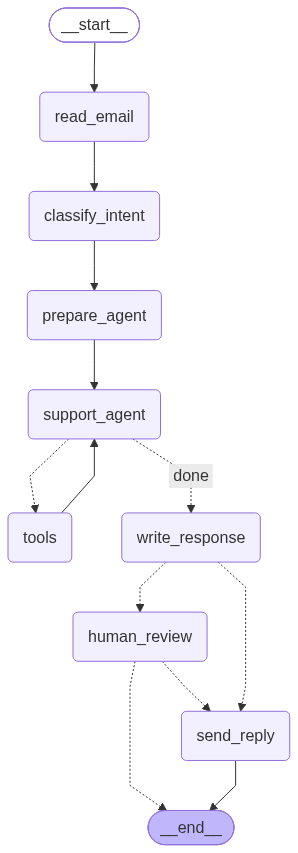

In [16]:
# Create the graph
builder = StateGraph(EmailAgentState)

# Nodes
builder.add_node("read_email", read_email)
builder.add_node("classify_intent", classify_intent)
builder.add_node("prepare_agent", prepare_agent)
builder.add_node("support_agent", support_agent)
builder.add_node("tools", tool_node)
builder.add_node("write_response", write_response)
builder.add_node("human_review", human_review)
builder.add_node("send_reply", send_reply)

# Main flow
builder.add_edge(START, "read_email")
builder.add_edge("read_email", "classify_intent")
builder.add_edge("classify_intent", "prepare_agent")
builder.add_edge("prepare_agent", "support_agent")

# Agent decides: tool or finished
builder.add_conditional_edges(
    "support_agent",
    route_after_agent,
    {
        "tools": "tools",
        "done": "write_response"
    }
)

# After a tool executes, go BACK to the agent.
builder.add_edge("tools", "support_agent")


builder.add_edge("send_reply", END)


# Compile with checkpointer for persistence
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
app = builder.compile(checkpointer = memory)

display(Image(app.get_graph().draw_mermaid_png()))

# Test

In [17]:
# Test with urgent billing issue
initial_state = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "sender_email": "customer@example.com",
    "email_id": "email_123"
}

# Run with a thread_id for persistence
config = {"configurable": {"thread_id": "customer_123"}}
result = app.invoke(initial_state, config)

In [18]:
result

{'email_content': 'I was charged twice for my subscription! This is urgent!',
 'sender_email': 'customer@example.com',
 'email_id': 'email_123',
 'classification': {'intent': 'billing',
  'urgency': 'critical',
  'topic': 'duplicate subscription charge'},
 'draft_response': 'I’m sorry — that sounds stressful. I’ll help get this fixed right away. To investigate and escalate as urgent, I need a few quick details from you:\n\nPlease reply with any of the following (whichever you have):\n- Account email (the one you use with us) or your order ID(s)\n- Date(s) and amount(s) of the charge(s)\n- Last 4 digits of the card used (optional but helpful)\n- A screenshot or photo of the bank/CC statement showing the two charges (if you can)\n- Whether you want us to cancel the duplicate subscription (yes/no)\n\nIf you want me to open an urgent support ticket now, say “Yes — open a ticket” and include at least your account email or an order ID. I’ll escalate immediately and confirm next steps and exp

In [19]:
# The graph will pause at human_review
print(f"Draft ready for review: {result['draft_response'][:60]}...\n")

# Provide human input to resume
human_response = Command(
    resume = {
        "approved": True
    }
)

# Resume execution
final_result = app.invoke(human_response, config)
print("Email sent successfully!")

Draft ready for review: I’m sorry — that sounds stressful. I’ll help get this fixed ...

Sending reply: I’m sorry — that sounds stressful. I’ll help get this fixed ...
Email sent successfully!


## More Examples

In [20]:
email_content = [
    "I was charged two times for my subscription! This is urgent!",
    "I was wondering if this was available in blue?",
    "Can you tell me how long the sale is on?",
    "The tire won't stay on the car!",
    "My subscription is going to end in a few months, what is the new rate?"
]
needs_approval = []

for i, content in enumerate(email_content): 

    initial_state = {
        "email_content": content,
        "sender_email": "customer@example.com",
        "email_id": f"email_{i}",
    }
    print(f"{initial_state['email_id']}: ", end="")

    thread_id = uuid.uuid4()
    config =  {"configurable": {"thread_id": thread_id}}
    result = app.invoke(initial_state, config)
    if "__interrupt__" in result.keys():
        result['thread_id'] = thread_id
        needs_approval.append(result)

email_0: email_1: Sending reply: Thanks — I can check that for you. Which item do you mean? P...
email_2: Sending reply: Which sale do you mean? I don’t have enough context to tell ...
email_3: email_4: Sending reply: I can look that up for you — I just need a couple details to...


In [21]:
needs_approval

[{'email_content': 'I was charged two times for my subscription! This is urgent!',
  'sender_email': 'customer@example.com',
  'email_id': 'email_0',
  'classification': {'intent': 'billing',
   'urgency': 'high',
   'topic': 'duplicate subscription charge'},
  'draft_response': 'Sorry about that — I’ll help get this fixed right away. To investigate and (if needed) refund the duplicate charge, I need a few details from you:\n\nPlease reply with:\n- Account email or order/subscription ID\n- Date(s) and amount(s) of the charge(s)\n- The last 4 digits of the card charged (do not send full card number)\n- A screenshot or photo of the bank/credit card statement showing the two charges (you can redact other sensitive info)\n- Any transaction IDs shown by your bank (if available)\n\nIf you prefer, I can open a high-priority support ticket and start the investigation as soon as you give me permission — I’ll need at least the account email or order/subscription ID to do that.\n\nA couple of qui

In [25]:
# Resume each interrupted email individually via input() prompts
needs_manual_followup = []

for item in needs_approval:
    config = {"configurable": {"thread_id": item["thread_id"]}}

    print(f"\n--- {item['email_id']} ({len(needs_approval)} total) ---")
    print(item["draft_response"])

    approve = input(f"[{item['email_id']}] Approve this response? (y/n): ").strip().lower() == "y"

    decision = {"approved": approve}
    if approve:
        edited = input("Edit the response? (press Enter to keep as-is): ").strip()
        if edited:
            decision["edited_response"] = edited
    else:
        needs_manual_followup.append(item["email_id"])

    try:
        human_response = Command(resume=decision)
        final_result = app.invoke(human_response, config)
        print(f"[{item['email_id']}] resolved -> {'sent' if approve else 'flagged for manual reply'}")
    except Exception as e:
        print(f"[{item['email_id']}] FAILED to resume: {e}")
        needs_manual_followup.append(item["email_id"])

print(f"\nDone. Needs manual follow-up: {needs_manual_followup or 'none'}")


--- email_0 (2 total) ---
Sorry about that — I’ll help get this fixed right away. To investigate and (if needed) refund the duplicate charge, I need a few details from you:

Please reply with:
- Account email or order/subscription ID
- Date(s) and amount(s) of the charge(s)
- The last 4 digits of the card charged (do not send full card number)
- A screenshot or photo of the bank/credit card statement showing the two charges (you can redact other sensitive info)
- Any transaction IDs shown by your bank (if available)

If you prefer, I can open a high-priority support ticket and start the investigation as soon as you give me permission — I’ll need at least the account email or order/subscription ID to do that.

A couple of quick notes while you gather that:
- Sometimes banks show a temporary authorization and the final charge only posts once; if one is “pending” it may disappear in a few days. If both are posted, we will investigate and refund any duplicate charge.
- Check your account’

In [26]:
print(f"\nDone. Needs manual follow-up: {needs_manual_followup or 'none'}")


Done. Needs manual follow-up: ['email_3']
